# DS 4320 Project 2 Pipeline

## Do News Signals Explain Betting Market Movement in the Masters?


## 1. Install Packages



In [1]:
!pip install --upgrade --force-reinstall \
  numpy==1.26.4 \
  pandas==2.2.2 \
  scipy==1.11.4 \
  scikit-learn==1.4.2 \
  pymongo dnspython certifi python-dotenv -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.11.4 which is incompatible.
inequality 1.1.2 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
pointpats 2.5.5 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
mapclassify 2.10.0 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.42 requires scikit-learn

## 2. Create `.env` File



## 3. Connect to MongoDB Atlas


In [3]:
import os
import certifi
from dotenv import load_dotenv
from pymongo import MongoClient

load_dotenv(".env")

MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(
    MONGO_URI,
    tls=True,
    tlsCAFile=certifi.where(),
    serverSelectionTimeoutMS=30000
)

print(client.list_database_names())


['masters_project', 'sample_mflix', 'admin', 'local']


## 4. Database and Collection Names


In [4]:
DB_NAME = "masters_project"

ODDS_COLLECTION = "odds_snapshots"
NEWS_COLLECTION = "news_articles"
PLAYER_COLLECTION = "player_snapshots"

db = client[DB_NAME]

print("Using database:", DB_NAME)


Using database: masters_project


## Data Collection and MongoDB Upload (External Notebook)

The raw data collection and MongoDB upload process was completed in a separate notebook. This was done to keep this notebook focused on analysis and to avoid repeatedly calling external APIs.

**Data Collection Notebook:**  

[https://colab.research.google.com/drive/1EZ5PoolPGCz7joGng1ur0qaEeYbB8e3N?usp=sharing]

## 5. Verify MongoDB Upload


In [5]:
print(client.list_database_names())

db = client[DB_NAME]

for c in db.list_collection_names():
    print(c, db[c].count_documents({}))


['masters_project', 'sample_mflix', 'admin', 'local']
news_articles 739
player_snapshots 26157
odds_snapshots 26157


## 6. Load Existing MongoDB Data for Analysis



In [8]:
import pandas as pd
player_docs = list(db[PLAYER_COLLECTION].find({}))

df = pd.json_normalize(player_docs)

df["_id"] = df["_id"].astype(str)
df["snapshot_time_utc"] = pd.to_datetime(df["snapshot_time_utc"])

print(df.shape)
display(df.head())


(26157, 32)


,_id,player_name,snapshot_time_utc,commence_time,event_id,event_name,requested_snapshot_time_utc,tournament,created_from.odds_collection,created_from.news_collection,...,news_features.avg_sentiment_24h,news_features.distinct_sources_24h,news_features.latest_article_age_hours,odds.average_american_price,odds.raw_implied_prob,odds.normalized_implied_prob,odds.sportsbook_quote_count,odds_change.average_american_price,odds_change.raw_implied_prob,odds_change.normalized_implied_prob
0,69f12ca5a7c28a2126dba3e7,Scottie Scheffler,2026-04-08 23:55:38+00:00,2026-04-09T11:40:00Z,b709a17e8bec948af575f4534c598144,Masters Tournament Winner,2026-04-09T00:00:00Z,Masters Tournament Winner,odds_snapshots,news_articles,...,0.0,0,NaN,571.666667,0.148883,0.110615,6,NaN,NaN,NaN
1,69f12ca5a7c28a2126dba3e8,Bryson DeChambeau,2026-04-08 23:55:38+00:00,2026-04-09T11:40:00Z,b709a17e8bec948af575f4534c598144,Masters Tournament Winner,2026-04-09T00:00:00Z,Masters Tournament Winner,odds_snapshots,news_articles,...,0.0,0,NaN,1091.666667,0.083916,0.062346,6,NaN,NaN,NaN
2,69f12ca5a7c28a2126dba3e9,Jon Rahm,2026-04-08 23:55:38+00:00,2026-04-09T11:40:00Z,b709a17e8bec948af575f4534c598144,Masters Tournament Winner,2026-04-09T00:00:00Z,Masters Tournament Winner,odds_snapshots,news_articles,...,0.0,0,NaN,1033.333333,0.088235,0.065555,6,NaN,NaN,NaN
3,69f12ca5a7c28a2126dba3ea,Ludvig Aberg,2026-04-08 23:55:38+00:00,2026-04-09T11:40:00Z,b709a17e8bec948af575f4534c598144,Masters Tournament Winner,2026-04-09T00:00:00Z,Masters Tournament Winner,odds_snapshots,news_articles,...,0.0,0,NaN,1583.333333,0.059406,0.044136,6,NaN,NaN,NaN
4,69f12ca5a7c28a2126dba3eb,Rory McIlroy,2026-04-08 23:55:38+00:00,2026-04-09T11:40:00Z,b709a17e8bec948af575f4534c598144,Masters Tournament Winner,2026-04-09T00:00:00Z,Masters Tournament Winner,odds_snapshots,news_articles,...,0.0,0,NaN,1320.833333,0.070381,0.052291,6,NaN,NaN,NaN


## 7. Feature Engineering and Target Variable



In [9]:
df = df.sort_values(["player_name", "snapshot_time_utc"]).copy()

df["next_normalized_prob"] = (
    df.groupby("player_name")["feature_vector.normalized_implied_prob"].shift(-1)
)

df["target_prob_up_next"] = (
    df["next_normalized_prob"] > df["feature_vector.normalized_implied_prob"]
).astype(int)

df[[
    "player_name",
    "snapshot_time_utc",
    "feature_vector.normalized_implied_prob",
    "next_normalized_prob",
    "target_prob_up_next"
]].head()


,player_name,snapshot_time_utc,feature_vector.normalized_implied_prob,next_normalized_prob,target_prob_up_next
54,Aaron Rai,2026-04-08 23:55:38+00:00,0.003171,0.001841,0
146,Aaron Rai,2026-04-09 00:10:38+00:00,0.001841,0.003169,1
238,Aaron Rai,2026-04-09 00:25:38+00:00,0.003169,0.003169,0
330,Aaron Rai,2026-04-09 00:40:38+00:00,0.003169,0.003169,0
422,Aaron Rai,2026-04-09 00:55:38+00:00,0.003169,0.003168,0


## 8. Define Modeling Datasets


1. **News-only model**
2. **Market + news model**



In [10]:
features_news = [
    "feature_vector.article_count_24h",
    "feature_vector.avg_sentiment_24h",
    "feature_vector.distinct_sources_24h",
    "feature_vector.latest_article_age_hours"
]

features_all = [
    "feature_vector.article_count_24h",
    "feature_vector.avg_sentiment_24h",
    "feature_vector.distinct_sources_24h",
    "feature_vector.latest_article_age_hours",
    "feature_vector.normalized_implied_prob",
    "feature_vector.odds_change_normalized_implied_prob",
    "feature_vector.sportsbook_quote_count"
]

target = "target_prob_up_next"

model_df_news = df[features_news + [target]].dropna().copy()
model_df_all = df[features_all + [target]].dropna().copy()

print("News-only model data:", model_df_news.shape)
print("Market + news model data:", model_df_all.shape)
print("\nTarget balance:")
print(model_df_all[target].value_counts(normalize=True))


News-only model data: (10102, 5)
Market + news model data: (10102, 8)

Target balance:
target_prob_up_next
0    0.648287
1    0.351713
Name: proportion, dtype: float64


## 9. Model Helper Function



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def run_logistic_model(model_df, features, target, model_name):
    X = model_df[features]
    y = model_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    coef_df = pd.DataFrame({
        "feature": features,
        "coefficient": model.coef_[0]
    }).sort_values("coefficient", ascending=False)

    return model, coef_df


## 10. Model 1 — News Only


In [12]:
model_news, coef_news = run_logistic_model(
    model_df_news,
    features_news,
    target,
    "Model 1: News Only"
)

display(coef_news)


Model 1: News Only
Accuracy: 0.49084611578426524

Confusion Matrix:
[[575 735]
 [294 417]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.44      0.53      1310
           1       0.36      0.59      0.45       711

    accuracy                           0.49      2021
   macro avg       0.51      0.51      0.49      2021
weighted avg       0.56      0.49      0.50      2021



,feature,coefficient
2,feature_vector.distinct_sources_24h,0.011213
1,feature_vector.avg_sentiment_24h,-0.002186
3,feature_vector.latest_article_age_hours,-0.004677
0,feature_vector.article_count_24h,-0.012469


## 11. Model 2 — Market + News


In [13]:
model_all, coef_all = run_logistic_model(
    model_df_all,
    features_all,
    target,
    "Model 2: Market + News"
)

display(coef_all)


Model 2: Market + News
Accuracy: 0.566056407718951

Confusion Matrix:
[[715 595]
 [282 429]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.55      0.62      1310
           1       0.42      0.60      0.49       711

    accuracy                           0.57      2021
   macro avg       0.57      0.57      0.56      2021
weighted avg       0.61      0.57      0.58      2021



,feature,coefficient
2,feature_vector.distinct_sources_24h,0.014174
4,feature_vector.normalized_implied_prob,0.003906
1,feature_vector.avg_sentiment_24h,-0.000462
5,feature_vector.odds_change_normalized_implied_...,-0.000676
3,feature_vector.latest_article_age_hours,-0.011158
0,feature_vector.article_count_24h,-0.012433
6,feature_vector.sportsbook_quote_count,-0.202294


## 12. Visualization — Implied Probability Over Time



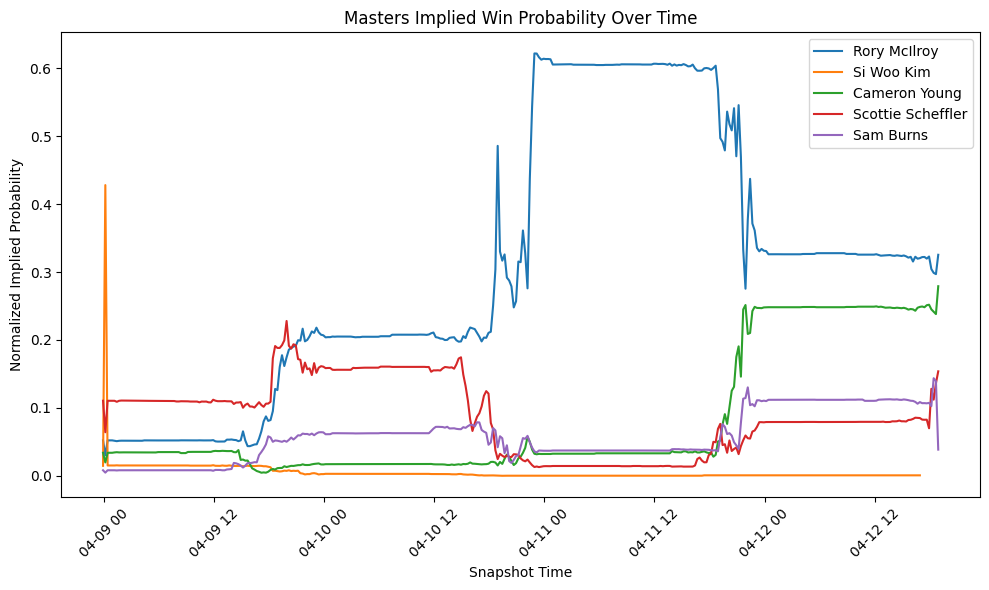

In [14]:
import matplotlib.pyplot as plt

top_players = (
    df.groupby("player_name")["feature_vector.normalized_implied_prob"]
    .max()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_df = df[df["player_name"].isin(top_players)]

plt.figure(figsize=(10, 6))

for player in top_players:
    temp = plot_df[plot_df["player_name"] == player]
    plt.plot(
        temp["snapshot_time_utc"],
        temp["feature_vector.normalized_implied_prob"],
        label=player
    )

plt.title("Masters Implied Win Probability Over Time")
plt.xlabel("Snapshot Time")
plt.ylabel("Normalized Implied Probability")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
